# TPC Repair Billing — Time-Series Forecast

A step-by-step walkthrough that builds a monthly average repair-bill forecast (from the eMARS TPC shutdown backup extract) and benchmarks **eight** approaches on the same hold-out.

**Flow of this notebook:**
1. **Load the data** and convert `CREATE_DATE` into a real datetime, then convert every bill to a common currency (§1).
2. **Build the monthly average** billed-amount series (§2).
3. **Two families of models** — understand feature-based ML vs. classical time-series methods (§3).
4. **Feature engineering** — turn the series into a supervised table for the ML models (§4).
5. **Machine-learning models** — RandomForest and HistGradientBoosting (incl. tuning), scored against naive baselines (§5).
6. **Classical models** — SARIMA, Prophet and ETS on the raw series (§6).
7. **Compare** everything on one leaderboard and pick a winner (§7).
8. **Forecast** the next 12 months with the winning model (§8).

In [1]:
# --- Core data + math libraries ---
import numpy as np            # numerical arrays (used for the linear time index)
import pandas as pd           # tables + time-series handling (the workhorse here)
import matplotlib.pyplot as plt   # plotting our series and forecasts

# --- The model and the metrics we score it with ---
from sklearn.ensemble import RandomForestRegressor   # tree-based regressor for the forecast
from sklearn.metrics import (
    mean_absolute_error,             # MAE  -> average error in dollars (easy to read)
    mean_absolute_percentage_error,  # MAPE -> average error as a % (scale-free)
    r2_score,                        # R²   -> how much variance the model explains
)

# Show floats as nicely formatted, comma-separated numbers (e.g. 656,734.36) everywhere.
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Path to the raw eMARS TPC (Terminal/Repair billing) shutdown backup CSV.
# One row = one repair-billing line item (TPC = "Terminal Processing Charge" repair estimate).
DATA_PATH = 'data/emars_tpc_shutdown_bkup.csv'

## 1. Load data, parse the date, and put every bill on a common currency

The raw file has one row per repair-billing line item, across many currencies. Each row also carries an `EXCH_RATE` — the number of local-currency units per US dollar for that transaction — so we can convert `BILL_AMOUNT` (the amount actually billed, after any waivers) into a single comparable unit: **US dollars**.

`CREATE_DATE` arrives as text, mixing `d/m/yyyy` and `d/m/yyyy h:mm:ss AM/PM` styles (e.g. `"20/8/2015 9:00:17 AM"`). `pd.to_datetime(..., dayfirst=True, format='mixed')` parses both styles unambiguously.

**Excluding 2019 onward:** the source system began migrating to a new platform partway through 2019, so records created from that point on aren't reliable for trend analysis. We drop them right after loading, keeping only stable, pre-migration data.

In [2]:
# Only pull the columns we actually need — this file has 1.5M+ rows, so trimming
# columns at read time (rather than dropping them after) keeps memory/parse time down.
df = pd.read_csv(DATA_PATH, usecols=['CREATE_DATE', 'BILL_AMOUNT', 'EXCH_RATE'])

# CREATE_DATE mixes a couple of text layouts, all day-first. format='mixed' lets
# pandas parse each row with whichever exact layout it matches, dayfirst=True
# resolves the ambiguous ones (e.g. "9/9/2015") the same way as the rest.
df['CREATE_DATE'] = pd.to_datetime(df['CREATE_DATE'], dayfirst=True, format='mixed')

# The source system began migrating to a new platform partway through 2019, and
# records created from that point on are not reliable for trend analysis. Drop
# everything from 2019 onward so the series only reflects stable, pre-migration data.
before_rows = len(df)
df = df[df['CREATE_DATE'].dt.year < 2019]
print(f'dropped {before_rows - len(df):,} rows from 2019 onward (system migration)')

# Convert every bill to US dollars using its own row's EXCH_RATE (local units per USD),
# so a S$16 bill and a ₹13,550.77 bill become directly comparable dollar figures.
df['BILL_AMOUNT_USD'] = df['BILL_AMOUNT'] / df['EXCH_RATE']

# Quick sanity checks: confirm the column is now a datetime and see the span we have.
print('dtype of CREATE_DATE column:', df['CREATE_DATE'].dtype)
print('date range:', df['CREATE_DATE'].min().date(), '->', df['CREATE_DATE'].max().date())
print('rows:', len(df))

# Peek at the few columns we care about for forecasting.
df[['CREATE_DATE', 'BILL_AMOUNT', 'EXCH_RATE', 'BILL_AMOUNT_USD']].head()

dropped 219,376 rows from 2019 onward (system migration)
dtype of CREATE_DATE column: datetime64[us]
date range: 2015-08-17 -> 2018-12-31
rows: 1289911


,CREATE_DATE,BILL_AMOUNT,EXCH_RATE,BILL_AMOUNT_USD
0,2015-09-09 18:15:20,8.00,1.00,8.00
1,2015-09-09 18:15:20,48.00,1.00,48.00
2,2015-09-03 13:48:19,16.00,1.41,11.33
3,2015-08-20 09:00:17,2.70,1.00,2.70
4,2015-08-20 09:00:18,25.50,1.00,25.50


## 2. Build the monthly time series

We forecast the **average billed amount per month (in USD)** across every repair line item, the same way the original walkthrough averaged resale price per month. Setting `CREATE_DATE` as a `DatetimeIndex` with a monthly frequency (`MS` = month-start) gives us a clean, gap-free series.

In [3]:
# Collapse over a million line items into ONE number per month: the average USD bill.
ts = (df.groupby(df['CREATE_DATE'].dt.to_period('M').dt.to_timestamp())['BILL_AMOUNT_USD']
        .mean()                             # -> average USD bill for that month
        .sort_index()                       # put months in chronological order
        .asfreq('MS'))                      # stamp a regular "Month-Start" frequency
# asfreq('MS') guarantees a row for EVERY month with no gaps. If a month had no
# line items it would show up as NaN here, which would break the lag features later.

print(f'{len(ts)} months from {ts.index.min().date()} to {ts.index.max().date()}')
print('any missing months?', ts.isna().any())   # we want this to be False
ts.tail()

41 months from 2015-08-01 to 2018-12-01
any missing months? False


CREATE_DATE
2018-08-01   17.25
2018-09-01   16.60
2018-10-01   17.66
2018-11-01   17.06
2018-12-01   15.92
Freq: MS, Name: BILL_AMOUNT_USD, dtype: float64

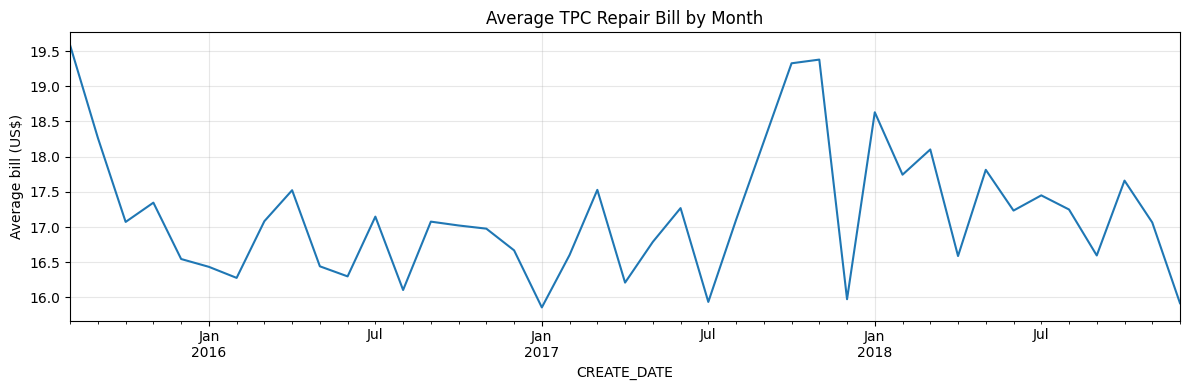

In [4]:
# Always LOOK at a time series before modelling it — your eyes catch trend,
# seasonality and outliers faster than any metric.
fig, ax = plt.subplots(figsize=(12, 4))    # one wide chart (wide = good for time axes)
ts.plot(ax=ax, color='#1f77b4')            # pandas plots the DatetimeIndex on the x-axis
ax.set_title('Average TPC Repair Bill by Month')
ax.set_ylabel('Average bill (US$)')
ax.grid(alpha=0.3)                         # faint gridlines for easier reading
plt.tight_layout()                         # stop labels getting clipped
plt.show()

## 3. Two families of models — and how we'll judge them

We'll pit two very different families against each other. They are *given different representations of the same data*, so it's worth understanding the distinction before we build anything.

**Machine-learning models** (RandomForest, HistGradientBoosting, MLP — §5) can't read a time axis on their own. They see a flat table of columns → target, so we must **hand-engineer** the time structure as features (done in §4):

| `FEATURE_COLS` | Meaning |
|---|---|
| `lag_1, lag_2, lag_3, lag_6, lag_12` | the value 1–12 months ago |
| `roll_mean_3` | 3-month rolling average |
| `month_of_year` | calendar month (seasonality) |
| `time_idx` | linear trend counter |

**Classical time-series models** (SARIMA, Prophet, ETS — §6) work straight from the **raw univariate series** (`ts`, or `ds`/`y` for Prophet) plus a seasonal period, and build their own internal structure — autoregressive/moving-average terms, differencing, or exponentially-weighted level/trend/season.

| Family | Input | Where the "features" come from |
|---|---|---|
| RandomForest, HistGradientBoosting, MLP | `feat[FEATURE_COLS]` | **you** engineer them (lags, rolling mean, calendar) |
| SARIMA, Prophet, ETS | raw `ts` series | the model derives them internally |

**The comparison stays fair** where it counts — every model uses the *identical* chronological train/test split, the *same* target, and the *same* 12-month hold-out. But keep in mind a large part of the ML models' edge comes from the features we pick, especially `lag_1` ("this month ≈ last month"). We'll also score everything against naive baselines, so we can see which models really earn their complexity.

## 4. Feature engineering (for the ML models)

We turn the series into a supervised-learning table. This feeds **only** the machine-learning models in §5 — the classical models in §6 skip it entirely. For each month we use:
- **Lag features** — average bills 1, 2, 3, 6 and 12 months ago (autoregression).
- **Rolling mean** — a 3-month moving average to capture local trend.
- **Calendar features** — month-of-year (seasonality) and a linear time index (overall trend).

In [5]:
# Which past months to look back at. lag_1 = last month, lag_12 = same month last year.
LAGS = [1, 2, 3, 6, 12]

def make_features(series):
    """Turn a single time series into a supervised table: one row per month,
    columns = clues from the PAST, target y = that month's actual average bill."""
    out = pd.DataFrame({'y': series})            # y is what we want to predict
    for lag in LAGS:
        # .shift(lag) moves values DOWN by `lag` rows, so each row sees the bill
        # from `lag` months earlier — never the future (no leakage).
        out[f'lag_{lag}'] = series.shift(lag)
    # 3-month moving average of the *prior* months -> smooths out local trend.
    # We shift(1) first so the current month is excluded from its own average.
    out['roll_mean_3'] = series.shift(1).rolling(3).mean()
    out['month_of_year'] = out.index.month       # 1-12: lets the model learn seasonality
    out['time_idx'] = np.arange(len(out))         # 0,1,2,... : a simple linear trend clock
    return out

# The earliest rows have no 12-month history yet, so their lag columns are NaN.
# dropna() removes those warm-up rows so every remaining row is fully populated.
feat = make_features(ts).dropna()
FEATURE_COLS = [c for c in feat.columns if c != 'y']   # everything except the target
feat.head()

,y,lag_1,lag_2,lag_3,lag_6,lag_12,roll_mean_3,month_of_year,time_idx
CREATE_DATE,,,,,,,,,
2016-08-01,16.10,17.15,16.30,16.44,16.28,19.58,16.63,8,12
2016-09-01,17.08,16.10,17.15,16.30,17.08,18.27,16.52,9,13
2016-10-01,17.02,17.08,16.10,17.15,17.52,17.07,16.78,10,14
2016-11-01,16.98,17.02,17.08,16.10,16.44,17.35,16.73,11,15
2016-12-01,16.67,16.98,17.02,17.08,16.30,16.55,17.02,12,16


## 5. Machine-learning models

First the chronological **train/test split** — time series must be split by time, **never shuffled**. We train on everything except the final 12 months and test on that recent year. (The classical models in §6 reuse this exact same hold-out, so every model is judged on the same window.)

We start with **RandomForest**, then add **HistGradientBoosting** and tune it.

In [6]:
TEST_MONTHS = 12
# Split by POSITION, not randomly: the first rows train, the LAST 12 months test.
# .iloc[:-12] = "everything up to the last 12"; .iloc[-12:] = "the final 12".
train, test = feat.iloc[:-TEST_MONTHS], feat.iloc[-TEST_MONTHS:]

# X = the input clues (lags, rolling mean, calendar); y = the bill we score against.
X_train, y_train = train[FEATURE_COLS], train['y']
X_test, y_test = test[FEATURE_COLS], test['y']

# A Random Forest = many decision trees averaged together.
#   n_estimators=400  -> 400 trees (more = steadier, slower)
#   min_samples_leaf=2 -> each leaf needs >=2 rows, which curbs overfitting
#   random_state=42   -> fixed seed so results are reproducible run to run
model = RandomForestRegressor(n_estimators=400, min_samples_leaf=2, random_state=42)
model.fit(X_train, y_train)        # learn patterns from the training years only

pred = model.predict(X_test)       # predict the held-out 12 months

# Score on data the model has NEVER seen. Note the R² can go negative when a model
# does worse than just predicting the mean — a useful reality check.
print(f'Test period: {test.index.min().date()} -> {test.index.max().date()}')
print(f'MAE : US$ {mean_absolute_error(y_test, pred):,.2f}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, pred) * 100:.2f}%')
print(f'R2  : {r2_score(y_test, pred):.3f}')

Test period: 2018-01-01 -> 2018-12-01
MAE : US$ 0.62
MAPE: 3.66%
R2  : -0.191


### Compare against naive baselines

A forecast is only useful if it beats the obvious guesses: *"next month = this month"* (naive) and *"next month = same month last year"* (seasonal naive).

In [7]:
# Two "free" baselines that require no model at all — we already have them as columns:
naive = test['lag_1']        # guess: next month = this month (last observed value)
seasonal = test['lag_12']    # guess: next month = the same month one year ago

# Score every contender on the SAME test months so the comparison is fair.
# A model that can't beat these simple rules isn't earning its complexity.
for name, p in [('Naive (lag-1)', naive),
                ('Seasonal naive (lag-12)', seasonal),
                ('RandomForest', pred)]:
    mae = mean_absolute_error(y_test, p)
    mape = mean_absolute_percentage_error(y_test, p) * 100
    # :<26 left-pads the name; :>9,.2f right-aligns the dollar figure with commas
    print(f'{name:<26} MAE US$ {mae:>9,.2f}   MAPE {mape:5.2f}%')

Naive (lag-1)              MAE US$      0.92   MAPE  5.30%
Seasonal naive (lag-12)    MAE US$      1.10   MAPE  6.28%
RandomForest               MAE US$      0.62   MAPE  3.66%


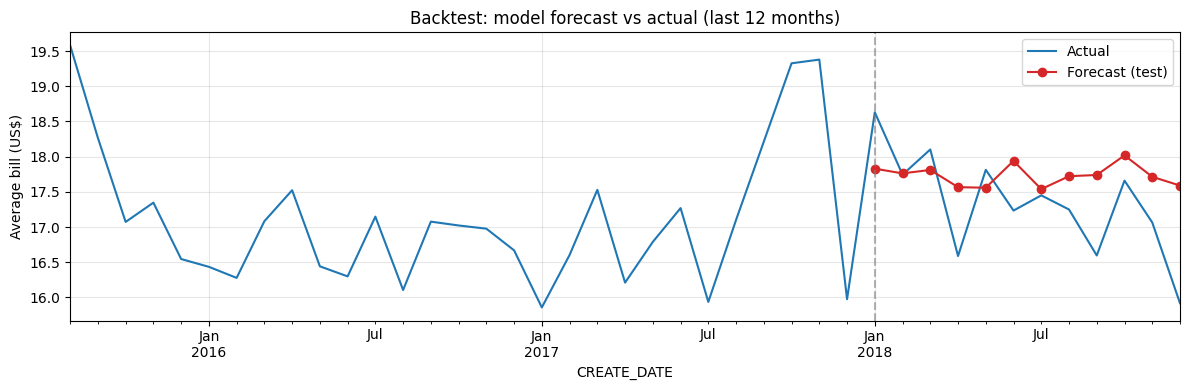

In [8]:
# Overlay the model's test-period forecast on the full actual history.
fig, ax = plt.subplots(figsize=(12, 4))
ts.plot(ax=ax, label='Actual', color='#1f77b4')   # the true line, every month in the extract
# Wrap the raw prediction array back into a Series so it lines up on the date axis.
pd.Series(pred, index=test.index).plot(ax=ax, label='Forecast (test)', color='#d62728', marker='o')
# Vertical line marks where training ends and the held-out test window begins.
ax.axvline(test.index.min(), color='gray', linestyle='--', alpha=0.6)
ax.set_title('Backtest: model forecast vs actual (last 12 months)')
ax.set_ylabel('Average bill (US$)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### HistGradientBoosting

`HistGradientBoostingRegressor` is scikit-learn's fast, modern gradient-boosting model (similar in spirit to LightGBM). Where a Random Forest builds many independent trees and **averages** them, gradient boosting builds trees **sequentially** — each new tree corrects the errors of the ones before it.

It trains on the **exact same feature table and split** as the RandomForest above, so the metrics are directly comparable.

In [9]:
from sklearn.ensemble import HistGradientBoostingRegressor   # sequential boosted trees

# Same X_train / y_train / X_test / y_test built back in Section 4 — fair comparison.
#   learning_rate=0.05 -> small steps, so each tree corrects errors gently (less overfit)
#   max_iter=400       -> up to 400 boosting rounds (trees added one after another)
#   max_leaf_nodes=15  -> keep individual trees shallow/simple
#   random_state=42    -> reproducible results
hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=400,
    max_leaf_nodes=15,
    random_state=42,
)
hgb.fit(X_train, y_train)          # learn on the training years only
hgb_pred = hgb.predict(X_test)     # predict the held-out 12 months

print(f'Test period: {test.index.min().date()} -> {test.index.max().date()}')
print(f'MAE : US$ {mean_absolute_error(y_test, hgb_pred):,.2f}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, hgb_pred) * 100:.2f}%')
print(f'R2  : {r2_score(y_test, hgb_pred):.3f}')

Test period: 2018-01-01 -> 2018-12-01
MAE : US$ 0.62
MAPE: 3.57%
R2  : -0.153


### Fine-tuning the gradient boosting model

Let's see if **systematic hyperparameter tuning** can improve on the default-ish settings above.

We use `GridSearchCV` with a `TimeSeriesSplit` — a CV scheme that **respects time order** (it always trains on earlier folds and validates on later ones, never the reverse). This avoids leaking future information into training, which a normal shuffled `KFold` would do on a time series.

We tune the knobs that most affect over/under-fitting: `learning_rate`, `max_iter`, `max_leaf_nodes`, `min_samples_leaf`, and `l2_regularization`.

In [10]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Grid of values to try for each hyperparameter. GridSearchCV trains a model for
# EVERY combination (here 3*3*3*2*3 = 162 combos) and keeps the best.
param_grid = {
    'learning_rate':      [0.01, 0.05, 0.1],   # step size of each boosting round
    'max_iter':           [200, 400, 800],     # number of boosting rounds (trees)
    'max_leaf_nodes':     [7, 15, 31],          # tree complexity (bigger = more flexible)
    'min_samples_leaf':   [5, 20],              # min rows per leaf (bigger = smoother)
    'l2_regularization':  [0.0, 1.0, 10.0],     # shrink predictions to fight overfitting
}

# TimeSeriesSplit: expanding-window CV. With n_splits=4 it makes 4 train/validation
# folds where each validation fold sits AFTER its training data — no peeking ahead.
tscv = TimeSeriesSplit(n_splits=4)

grid = GridSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',   # optimise for low MAE (sklearn maximises, hence "neg")
    n_jobs=-1,                            # use all CPU cores
)
grid.fit(X_train, y_train)               # search happens on the TRAINING data only

print('Best params:', grid.best_params_)
print(f'Best CV MAE: US$ {-grid.best_score_:,.2f}')

# Evaluate the tuned model on the untouched 12-month test set.
hgb_tuned = grid.best_estimator_
hgb_tuned_pred = hgb_tuned.predict(X_test)

print(f'\nTuned HGB on test set ({test.index.min().date()} -> {test.index.max().date()}):')
print(f'MAE : US$ {mean_absolute_error(y_test, hgb_tuned_pred):,.2f}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, hgb_tuned_pred) * 100:.2f}%')
print(f'R2  : {r2_score(y_test, hgb_tuned_pred):.3f}')

Best params: {'l2_regularization': 1.0, 'learning_rate': 0.01, 'max_iter': 800, 'max_leaf_nodes': 7, 'min_samples_leaf': 5}
Best CV MAE: US$ 0.90

Tuned HGB on test set (2018-01-01 -> 2018-12-01):
MAE : US$ 0.72
MAPE: 4.10%
R2  : -0.452


**Lessons for learners:**
- A model's *first* score is rarely its *best* score — disciplined tuning can be the difference between worst and near-best.
- Always tune with a **time-aware** CV (`TimeSeriesSplit`), not shuffled folds, or your validation scores will be optimistic.
- Compare the tuned score above to the untuned score and to the naive baselines in the leaderboard (§7) to see how much tuning actually bought you on this series.

### MLP (Multi-Layer Perceptron neural network)

`MLPRegressor` is a small feed-forward neural network — one or more hidden layers of neurons, each learning a weighted, non-linearly-activated combination of the inputs. It's a third contender in the ML family, alongside RandomForest and HistGradientBoosting, trained on the **exact same feature table and split**.

Unlike the tree models, neural networks are **sensitive to input scale** — a `lag_1` in the tens and a `month_of_year` from 1–12 sitting on wildly different scales can make training unstable. So we standardize every feature (mean 0, standard deviation 1) with a `StandardScaler`, fit only on the training rows, before handing them to the network. `Pipeline` bundles the scaler and the model together so this happens automatically and consistently on both train and test data.

In [11]:
from sklearn.neural_network import MLPRegressor    # feed-forward neural network regressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline = "always scale first, then feed the scaled features to the network."
# hidden_layer_sizes=(64, 32) -> two hidden layers (64 neurons, then 32)
# early_stopping=True         -> holds out part of the training data internally to
#                                stop once validation error stops improving (fights overfitting)
# max_iter=2000               -> allow enough training passes to converge
# random_state=42             -> reproducible results
mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(hidden_layer_sizes=(64, 32),
                         activation='relu',
                         early_stopping=True,
                         max_iter=2000,
                         random_state=42)),
])
mlp.fit(X_train, y_train)          # scaler fits on TRAIN only, then transforms + fits the network
mlp_pred = mlp.predict(X_test)     # predict the held-out 12 months (scaler transforms X_test too)

print(f'Test period: {test.index.min().date()} -> {test.index.max().date()}')
print(f'MAE : US$ {mean_absolute_error(y_test, mlp_pred):,.2f}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, mlp_pred) * 100:.2f}%')
print(f'R2  : {r2_score(y_test, mlp_pred):.3f}')

Test period: 2018-01-01 -> 2018-12-01
MAE : US$ 7.09
MAPE: 41.50%
R2  : -165.772


**Why scaling matters here:** without it, a feature like `lag_1` (values in the teens) and `time_idx` (values up to ~40) would dominate the network's early gradients purely because of their size, not their actual predictive value — the network would waste capacity learning to compensate for scale instead of pattern. Trees (RandomForest, HistGradientBoosting) split on raw thresholds so they don't have this problem, which is why only the MLP step needed a `Pipeline` with a scaler.

## 6. Classical time-series models (on the raw series)

Now the other family. These models **ignore the engineered feature table** and work directly from the raw monthly series `ts`, on the **same last-12-months hold-out** as §5 — so their MAE/MAPE are directly comparable.

### SARIMA

**In plain English:** SARIMA is a classic statistical forecasting recipe. You hand it the price history and it learns three things at once: (1) the overall **direction** the average bill is drifting (trend), (2) how strongly **last month's value carries into this month** (momentum), and (3) any **repeating yearly pattern** (e.g. bills always dip in a certain month). It then combines those to project the next months — no hand-made features needed.

The name spells out its parts: **S**easonal + **A**uto**R**egressive ("this month depends on recent months") + **I**ntegrated ("model the month-to-month *changes* rather than raw values, to handle the trend") + **M**oving **A**verage ("also learn from recent surprise jumps"). The settings below — `order=(1,1,1)` and `seasonal_order=(1,1,1,12)` — just say "use one step of each part, with a 12-month seasonal cycle." The code comments break down each number.

> Requires `statsmodels` (`pip install statsmodels`).

In [12]:
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX   # the classical seasonal ARIMA model

# Same hold-out as Section 4: last 12 months are the test set.
# Here we feed SARIMA the RAW series (it builds its own internal structure) — no
# manual lag table needed, unlike the Random Forest.
ts_train, ts_test = ts.iloc[:-TEST_MONTHS], ts.iloc[-TEST_MONTHS:]

# SARIMA(p,d,q)(P,D,Q,s): non-seasonal (1,1,1), seasonal (1,1,1) with yearly period s=12.
#   d=1  -> difference once to remove any trend
#   D=1, s=12 -> seasonal differencing across the 12-month cycle
#   the (1,_,1) terms capture short-term autocorrelation (AR) and shocks (MA)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')   # silence convergence/freq chatter
    sarima = SARIMAX(ts_train,
                     order=(1, 1, 1),
                     seasonal_order=(1, 1, 1, 12),
                     enforce_stationarity=False,   # let the optimizer be flexible
                     enforce_invertibility=False).fit(disp=False)

# SARIMA forecasts the whole horizon in one shot (not recursively row-by-row).
sarima_fc = sarima.forecast(steps=TEST_MONTHS)
sarima_fc.index = ts_test.index   # align index so metrics/plot line up with actuals

print(f'Test period: {ts_test.index.min().date()} -> {ts_test.index.max().date()}')
print(f'MAE : US$ {mean_absolute_error(ts_test, sarima_fc):,.2f}')
print(f'MAPE: {mean_absolute_percentage_error(ts_test, sarima_fc) * 100:.2f}%')
print(f'R2  : {r2_score(ts_test, sarima_fc):.3f}')

Test period: 2018-01-01 -> 2018-12-01
MAE : US$ 4.67
MAPE: 27.17%
R2  : -53.240


### Prophet

[Prophet](https://facebook.github.io/prophet/) (from Meta) decomposes a series into **trend + seasonality + holidays**, fitting them as smooth additive components. Unlike the tree models, **Prophet's trend can extrapolate** beyond historical highs or lows.

Prophet expects columns named **`ds`** (date) and **`y`** (value); same hold-out as before.

> Requires `prophet` (`pip install prophet`).

In [13]:
import logging
from prophet import Prophet

# Prophet is chatty — silence its informational logging for a clean notebook.
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# Prophet wants two columns named exactly 'ds' (datestamp) and 'y' (value).
# Rebuild the train/test frames from the raw monthly series `ts`.
prophet_train = (ts.iloc[:-TEST_MONTHS]
                   .rename_axis('ds').reset_index(name='y'))

# yearly_seasonality=True models the 12-month cycle; the series is monthly so we
# turn off the (irrelevant) weekly/daily seasonalities.
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(prophet_train)

# Ask Prophet for a future frame covering the 12 held-out months, then predict.
future = m.make_future_dataframe(periods=TEST_MONTHS, freq='MS')
prophet_out = m.predict(future)

# Keep only the test-window predictions ('yhat'), aligned to the test index.
prophet_fc = prophet_out.set_index('ds')['yhat'].iloc[-TEST_MONTHS:]
prophet_fc.index = test.index   # align for metrics/plot

print(f'Test period: {test.index.min().date()} -> {test.index.max().date()}')
print(f'MAE : US$ {mean_absolute_error(y_test, prophet_fc):,.2f}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, prophet_fc) * 100:.2f}%')
print(f'R2  : {r2_score(y_test, prophet_fc):.3f}')

Importing plotly failed. Interactive plots will not work.


07:01:48 - cmdstanpy - INFO - Chain [1] start processing


07:01:49 - cmdstanpy - INFO - Chain [1] done processing


Test period: 2018-01-01 -> 2018-12-01
MAE : US$ 1.51
MAPE: 8.79%
R2  : -4.692


### ETS — Exponential Smoothing (Holt-Winters)

**ETS** (Error, Trend, Seasonal) — aka **Holt-Winters** — keeps running, exponentially-weighted estimates of three components: the **level**, the **trend**, and the **seasonal** pattern, giving more weight to recent observations. It's lighter than SARIMA but built for the same job.

We fit an additive trend + additive yearly seasonality model on the same split.

> Uses `statsmodels` (already installed for SARIMA).

In [14]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Same hold-out as Section 4: ts_train / ts_test were defined alongside SARIMA.
# trend='add'      -> additive (linear) trend component
# seasonal='add'   -> additive yearly season, seasonal_periods=12 months
with warnings.catch_warnings():
    warnings.simplefilter('ignore')   # silence convergence chatter on a short series
    ets = ExponentialSmoothing(ts_train,
                               trend='add',
                               seasonal='add',
                               seasonal_periods=12,
                               initialization_method='estimated').fit()

# forecast() projects the next TEST_MONTHS steps in one shot.
ets_fc = ets.forecast(TEST_MONTHS)
ets_fc.index = ts_test.index   # align index for metrics/plot

print(f'Test period: {ts_test.index.min().date()} -> {ts_test.index.max().date()}')
print(f'MAE : US$ {mean_absolute_error(ts_test, ets_fc):,.2f}')
print(f'MAPE: {mean_absolute_percentage_error(ts_test, ets_fc) * 100:.2f}%')
print(f'R2  : {r2_score(ts_test, ets_fc):.3f}')

Test period: 2018-01-01 -> 2018-12-01
MAE : US$ 0.88
MAPE: 5.04%
R2  : -1.233


## 7. Compare all models

Every model has now been scored on the identical 12-month hold-out. Time to rank them and plot them head-to-head.

In [15]:
# Collect every model's scores into one tidy table for an apples-to-apples ranking.
results = []
for name, p in [('Naive (lag-1)', test['lag_1']),
                ('Seasonal naive (lag-12)', test['lag_12']),
                ('RandomForest', pred),
                ('HistGradientBoosting (untuned)', hgb_pred),
                ('HistGradientBoosting (tuned)', hgb_tuned_pred),
                ('MLP (Neural Network)', mlp_pred),
                ('SARIMA', sarima_fc.values),
                ('Prophet', prophet_fc.values),
                ('ETS / Holt-Winters', ets_fc.values)]:
    results.append({
        'model': name,
        'MAE (US$)': mean_absolute_error(y_test, p),
        'MAPE (%)': mean_absolute_percentage_error(y_test, p) * 100,
        'R2': r2_score(y_test, p),
    })

# Build the DataFrame and sort so the best (lowest MAE) model sits on top.
leaderboard = pd.DataFrame(results).set_index('model').sort_values('MAE (US$)')
leaderboard

,MAE (US$),MAPE (%),R2
model,,,
RandomForest,0.62,3.66,-0.19
HistGradientBoosting (untuned),0.62,3.57,-0.15
HistGradientBoosting (tuned),0.72,4.10,-0.45
ETS / Holt-Winters,0.88,5.04,-1.23
Naive (lag-1),0.92,5.30,-1.58
Seasonal naive (lag-12),1.10,6.28,-2.94
Prophet,1.51,8.79,-4.69
SARIMA,4.67,27.17,-53.24
MLP (Neural Network),7.09,41.50,-165.77


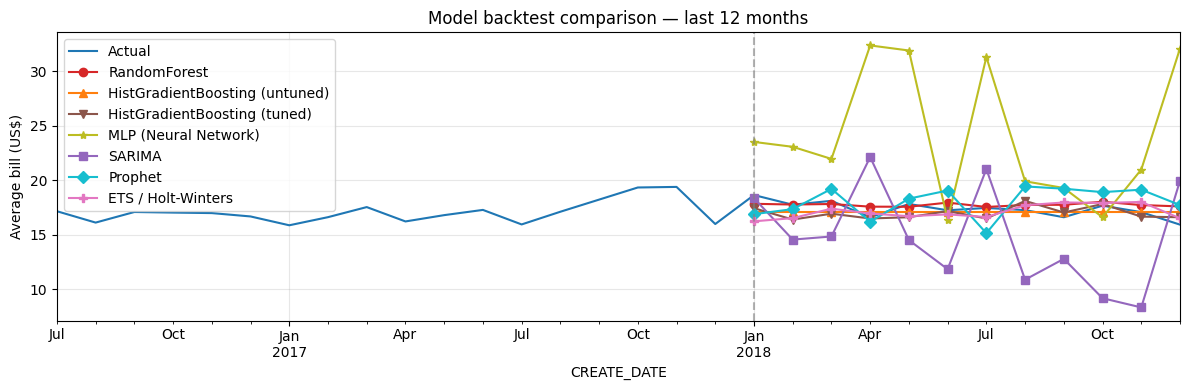

In [16]:
# Zoom in on the recent window so the test-period differences are easy to see.
fig, ax = plt.subplots(figsize=(12, 4))
ts.iloc[-30:].plot(ax=ax, label='Actual', color='#1f77b4')   # last 30 months of truth
pd.Series(pred, index=test.index).plot(ax=ax, label='RandomForest', color='#d62728', marker='o')
pd.Series(hgb_pred, index=test.index).plot(ax=ax, label='HistGradientBoosting (untuned)', color='#ff7f0e', marker='^')
pd.Series(hgb_tuned_pred, index=test.index).plot(ax=ax, label='HistGradientBoosting (tuned)', color='#8c564b', marker='v')
pd.Series(mlp_pred, index=test.index).plot(ax=ax, label='MLP (Neural Network)', color='#bcbd22', marker='*')
sarima_fc.plot(ax=ax, label='SARIMA', color='#9467bd', marker='s')   # square markers
pd.Series(prophet_fc.values, index=test.index).plot(ax=ax, label='Prophet', color='#17becf', marker='D')  # diamonds
pd.Series(ets_fc.values, index=test.index).plot(ax=ax, label='ETS / Holt-Winters', color='#e377c2', marker='P')  # plus
ax.axvline(ts_test.index.min(), color='gray', linestyle='--', alpha=0.6)  # train/test boundary
ax.set_title('Model backtest comparison — last 12 months')
ax.set_ylabel('Average bill (US$)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Verdict

Check `leaderboard` above for the exact ranking on this dataset — unlike a hand-picked example, the winner here depends on this series' own trend/seasonality mix, so read the table rather than assuming any one model "should" win.

**General lessons that carry over regardless of which model tops the table:**
- A more sophisticated or "modern" model is *not* a guaranteed win — always backtest against simple baselines (`Naive`, `Seasonal naive`) on the same split.
- Tuning matters: compare the tuned vs. untuned HistGradientBoosting rows to see how much a time-aware hyperparameter search bought you here.
- SARIMA, ETS, and Prophet all commit to an explicit seasonal assumption; if this series has only weak yearly seasonality, that assumption can hurt more than it helps — the leaderboard will show it.
- Tree models (RandomForest, HistGradientBoosting) **cannot extrapolate** beyond the range of values seen in training, which matters if the series is trending strongly up or down at the end of the hold-out.

## 8. Forecast the next 12 months with the winning model

Pick whichever model topped the leaderboard in §7. The code below defaults to **RandomForest**, mirroring the model built in §5 — swap in a different fitted model/feature table if your leaderboard crowns a different winner. We refit on the **full** series, then forecast **recursively**: each predicted month is fed back in as a lag to predict the next one.

In [17]:
# For the REAL future we have no held-out data, so refit on ALL months available.
full_model = RandomForestRegressor(n_estimators=400, min_samples_leaf=2, random_state=42)
full_model.fit(feat[FEATURE_COLS], feat['y'])

HORIZON = 12                                  # how many months ahead to forecast
history = ts.copy()                           # working copy we'll keep appending to
# Generate the 12 future month-start dates that come right after our last real month.
future_dates = pd.date_range(ts.index.max() + pd.offsets.MonthBegin(1),
                             periods=HORIZON, freq='MS')

preds = []
for date in future_dates:
    # Build this future month's feature row from the most recent `history` values.
    # history.iloc[-lag] reaches back `lag` months from the current end of history.
    row = {f'lag_{lag}': history.iloc[-lag] for lag in LAGS}
    row['roll_mean_3'] = history.iloc[-3:].mean()   # avg of the latest 3 months
    row['month_of_year'] = date.month
    row['time_idx'] = len(history)
    X_next = pd.DataFrame([row])[FEATURE_COLS]      # one-row frame, columns in order
    yhat = full_model.predict(X_next)[0]            # predict this single month
    preds.append(yhat)
    # KEY STEP — "recursive" forecasting: append the prediction to history so the
    # NEXT loop iteration can use it as a lag. Errors can therefore compound forward.
    history.loc[date] = yhat

forecast = pd.Series(preds, index=future_dates, name='forecast')
forecast

2019-01-01   17.30
2019-02-01   17.14
2019-03-01   17.06
2019-04-01   17.18
2019-05-01   16.97
2019-06-01   17.12
2019-07-01   16.94
2019-08-01   16.96
2019-09-01   16.97
2019-10-01   16.92
2019-11-01   16.97
2019-12-01   16.62
Freq: MS, Name: forecast, dtype: float64

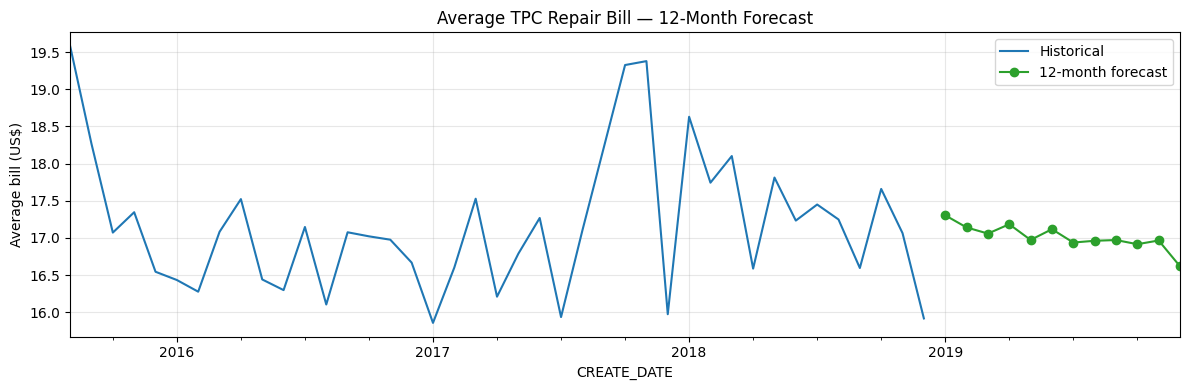

In [18]:
# Plot history and the forward forecast on one continuous time axis.
fig, ax = plt.subplots(figsize=(12, 4))
ts.plot(ax=ax, label='Historical', color='#1f77b4')        # what actually happened
forecast.plot(ax=ax, label='12-month forecast', color='#2ca02c', marker='o')  # what we project
ax.set_title('Average TPC Repair Bill — 12-Month Forecast')
ax.set_ylabel('Average bill (US$)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
# Notice the forecast flattens out — tree models can't extrapolate a trend
# beyond values they saw in training (see the closing notes).

## Notes & next steps

- `CREATE_DATE` is now a true `datetime64`, so you can slice by date, resample, and plot on a time axis.
- **2019-onward records were dropped** at load time because of the system migration — the series and every model here only reflect Aug-2015 through Dec-2018.
- Every bill was converted to **USD** using its own row's `EXCH_RATE` before aggregating — mixing raw local-currency amounts across `CURRENCY_CODE`s would have made the monthly average meaningless.
- **Recursive forecasting compounds error** — accuracy degrades the further out you go; trust near-term months most.
- Tree models **cannot extrapolate trend** beyond the training range; the `time_idx` feature only helps within it. If the average bill keeps drifting past historical extremes, consider a model that extrapolates (`LinearRegression` on trend, or lean on SARIMA / Holt-Winters instead).
- You could forecast per `PORT_CODE`, `TPC_PARTNER_CODE`, or `REPAIR_CODE` by grouping before building the series — or filter to `TPC_STATUS == 'COMPLETED'` only if you want finalized bills rather than every raised/pending/excess line item.